# Tugas Analisis Multimedia: **Image (Citra Digital)**

**Mata Kuliah:** Sistem & Teknologi Multimedia  
**Nama:** Catur Widiatama 
**NIM:** 122400034 

---

## Deskripsi Tugas

Tugas ini bertujuan untuk memahami **representasi dasar data citra digital (image)** melalui praktik langsung memuat data, visualisasi komponen warna, serta melakukan analisis spasial sederhana menggunakan berbagai teknik dasar pengolahan citra.

Anda akan bekerja dengan satu atau beberapa gambar (foto diri, objek, atau lingkungan sekitar) untuk:

* Mengamati struktur data piksel dan channel warna (RGB, Grayscale, HSV, dsb.)
* Menganalisis perbedaan hasil visualisasi antar representasi warna
* Melakukan eksplorasi sederhana terhadap transformasi citra (cropping, filtering, edge detection, dll.)
* Menyimpulkan pengaruh setiap tahap pemrosesan terhadap persepsi visual

Fokus tugas ini adalah pada **pemahaman konsep representasi spasial citra digital** dan **interpretasi hasil visualisasi**, **bukan** pada manipulasi kompleks atau penerapan model pembelajaran mesin.

### **Soal 1 — Cropping dan Konversi Warna**

* Ambil sebuah gambar diri Anda (*selfie*) menggunakan kamera atau smartphone.
* Lakukan **cropping secara manual** untuk menghasilkan dua potongan:

  * Cropping **kotak persegi pada area wajah**.
  * Cropping **persegi panjang pada area latar belakang**.
* Resize hasil crop menjadi **920×920 piksel**.
* Konversi gambar menjadi **grayscale** dan **HSV**, lalu tampilkan ketiganya berdampingan.
* Tambahkan **anotasi teks** berisi nama Anda di atas kepala pada gambar hasil crop.

  * Gaya teks (font, warna, posisi, ukuran, ketebalan) **dibebaskan**.
* Jelaskan efek **cropping** dan **perubahan warna** menggunakan **Markdown**.


Ukuran gambar asli : (1200, 1600, 3)


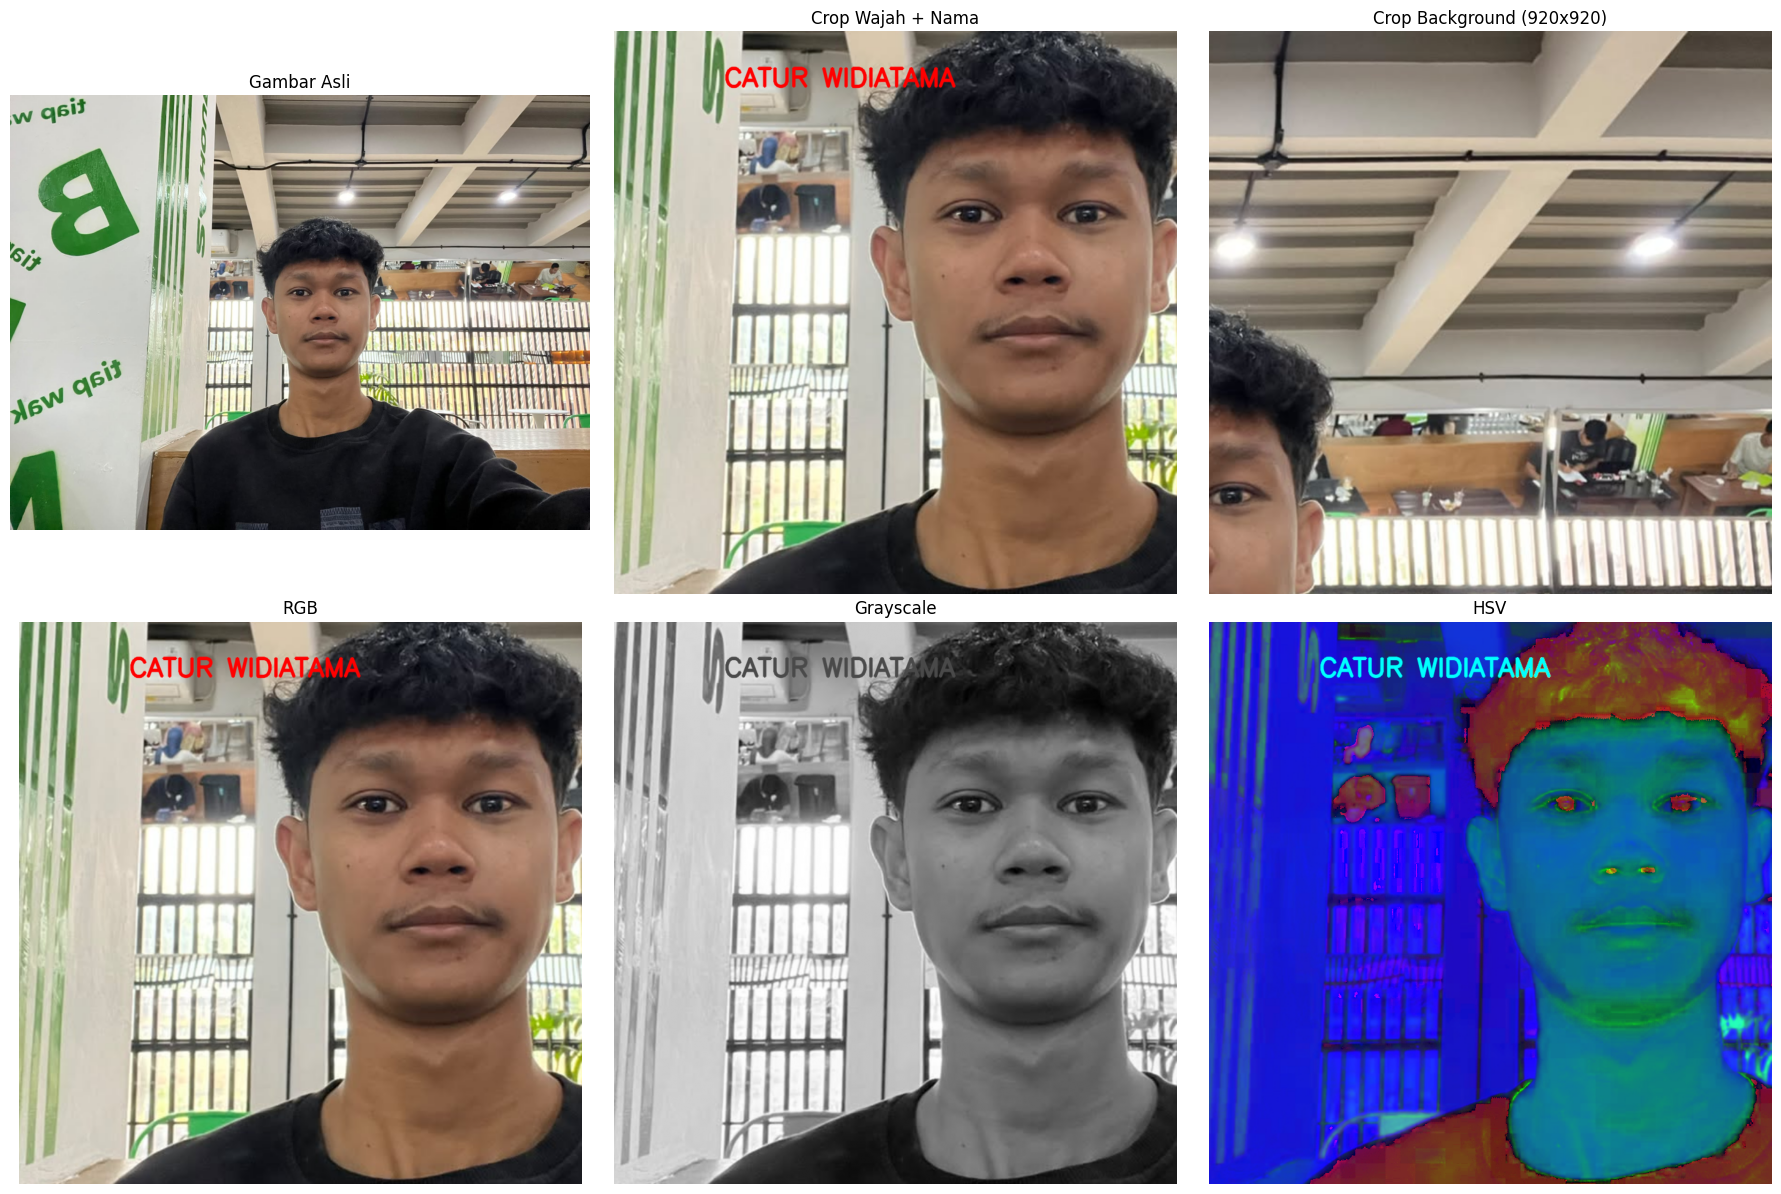

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# ==========================================
# BACA GAMBAR
# ==========================================
IMAGE_PATH = os.path.join("data", "selfiecatur.jpeg")

img = cv2.imread(IMAGE_PATH)

if img is None:
    raise FileNotFoundError(f"Gambar tidak ditemukan: {IMAGE_PATH}")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

print("Ukuran gambar asli :", img.shape)

# ==========================================
# CROPPING WAJAH (PERSEGI)
# ==========================================
face_crop = img_rgb[
    350:950,    # y1:y2
    420:1020    # x1:x2
]

# ==========================================
# CROPPING BACKGROUND (PERSEGI PANJANG)
# ==========================================
background_crop = img_rgb[
    50:650,     # y1:y2
    900:1500    # x1:x2
]

# ==========================================
# RESIZE MENJADI 920x920
# ==========================================
face_resize = cv2.resize(face_crop, (920, 920))
background_resize = cv2.resize(background_crop, (920, 920))

# ==========================================
# TAMBAHKAN NAMA
# ==========================================
face_annotated = face_resize.copy()

cv2.putText(
    face_annotated,
    "CATUR WIDIATAMA",
    (180, 90),
    cv2.FONT_HERSHEY_SIMPLEX,
    1.4,
    (255, 0, 0),
    3,
    cv2.LINE_AA
)

# ==========================================
# KONVERSI WARNA
# ==========================================
gray = cv2.cvtColor(face_annotated, cv2.COLOR_RGB2GRAY)
hsv = cv2.cvtColor(face_annotated, cv2.COLOR_RGB2HSV)

# ==========================================
# TAMPILKAN HASIL
# ==========================================
plt.figure(figsize=(18, 12))

plt.subplot(2,3,1)
plt.imshow(img_rgb)
plt.title("Gambar Asli")
plt.axis("off")

plt.subplot(2,3,2)
plt.imshow(face_annotated)
plt.title("Crop Wajah + Nama")
plt.axis("off")

plt.subplot(2,3,3)
plt.imshow(background_resize)
plt.title("Crop Background (920x920)")
plt.axis("off")

plt.subplot(2,3,4)
plt.imshow(face_annotated)
plt.title("RGB")
plt.axis("off")

plt.subplot(2,3,5)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(2,3,6)
plt.imshow(hsv)
plt.title("HSV")
plt.axis("off")

plt.tight_layout()
plt.show()


# Analisis Cropping dan Konversi Warna

## Cropping

Cropping dilakukan untuk mengambil bagian tertentu dari gambar sehingga fokus analisis dapat diarahkan pada objek yang diinginkan.

Pada percobaan ini dilakukan dua jenis cropping:

1. Cropping persegi pada area wajah.
2. Cropping persegi panjang pada area latar belakang.

Dengan cropping, informasi yang tidak diperlukan dapat dihilangkan sehingga objek utama menjadi lebih fokus.

## Resize

Hasil cropping kemudian diubah ukurannya menjadi 920 × 920 piksel.

Tujuan resize adalah:

- Menyamakan ukuran citra.
- Memudahkan visualisasi.
- Menyiapkan data untuk proses pengolahan citra berikutnya.

## Grayscale

Grayscale mengubah citra berwarna menjadi citra satu kanal intensitas.

Karakteristik:

- Tidak memiliki informasi warna.
- Hanya menampilkan tingkat kecerahan.
- Lebih sederhana untuk analisis citra.

## HSV

HSV terdiri dari:

- Hue (warna)
- Saturation (kejenuhan)
- Value (kecerahan)

Model HSV lebih mudah digunakan untuk segmentasi warna dibandingkan RGB.

## Anotasi Teks

Nama ditambahkan menggunakan fungsi OpenCV `cv2.putText()` pada bagian atas kepala untuk memberikan identitas pada citra hasil pengolahan.

### **Soal 2 — Manipulasi Channel Warna RGB**

* Gunakan gambar hasil crop dari Soal 1.
* Konversikan gambar ke ruang warna **RGB**.
* Lakukan manipulasi channel warna dengan cara:

  * **Naikkan intensitas channel merah sebanyak 50 poin** (maksimum 255).
  * **Turunkan intensitas channel biru sebanyak 30 poin** (minimum 0).
* Teknik atau cara menaikkan/menurunkan intensitas **dibebaskan**, asalkan logis dan hasilnya terlihat.
* Gabungkan kembali channel warna dan **simpan gambar hasil modifikasi dalam format `.png`**.
* **Tampilkan histogram per channel (R, G, B)** untuk gambar asli dan hasil modifikasi menggunakan `matplotlib.pyplot.hist`.
* Jelaskan dampak perubahan RGB pada warna gambar dalam sel **Markdown**.


File berhasil disimpan: hasil_modifikasi_rgb.png


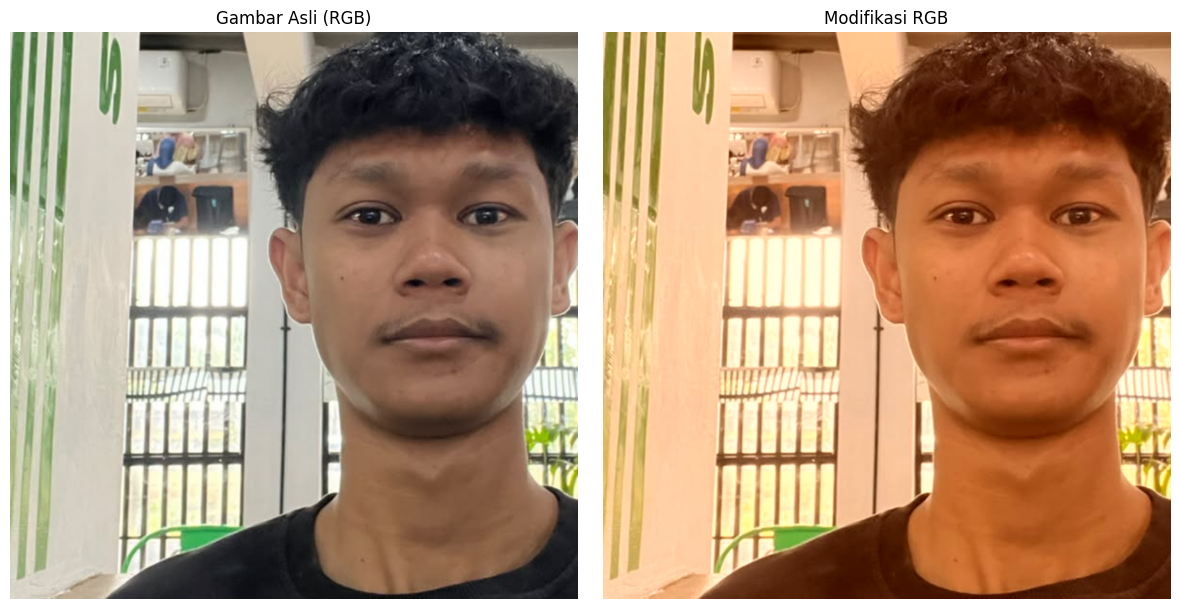

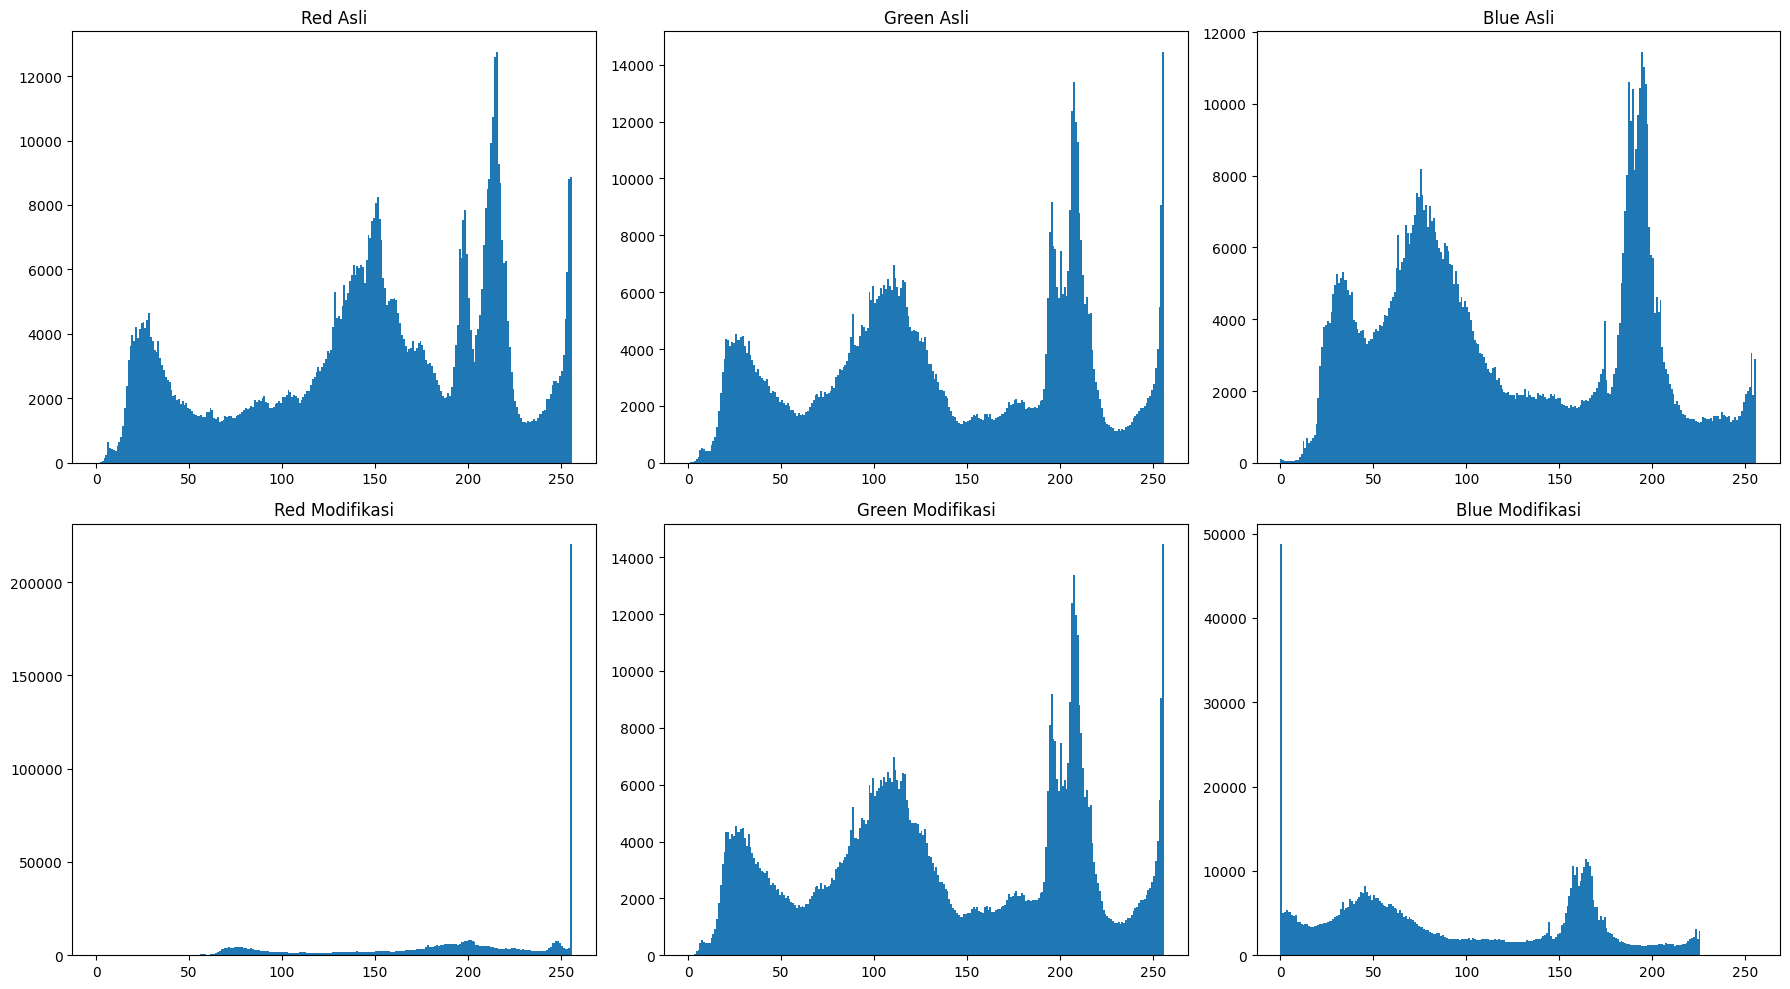

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# ==========================================
# BACA GAMBAR
# ==========================================
IMAGE_PATH = os.path.join("data", "selfiecatur.jpeg")

img = cv2.imread(IMAGE_PATH)

if img is None:
    raise FileNotFoundError(f"Gambar tidak ditemukan: {IMAGE_PATH}")

# BGR -> RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# ==========================================
# CROP WAJAH (HASIL SOAL 1)
# ==========================================
face_crop = img_rgb[
    350:950,
    420:1020
]

# Resize 920 x 920
face_resize = cv2.resize(face_crop, (920, 920))

# ==========================================
# SPLIT CHANNEL RGB
# ==========================================
R = face_resize[:, :, 0].copy()
G = face_resize[:, :, 1].copy()
B = face_resize[:, :, 2].copy()

# ==========================================
# MODIFIKASI CHANNEL
# Merah +50
# Biru -30
# ==========================================
R_mod = np.clip(R.astype(np.int16) + 50, 0, 255).astype(np.uint8)
B_mod = np.clip(B.astype(np.int16) - 30, 0, 255).astype(np.uint8)

# Gabungkan kembali
modified_img = cv2.merge([R_mod, G, B_mod])

# ==========================================
# SIMPAN HASIL PNG
# ==========================================
output_file = "hasil_modifikasi_rgb.png"

cv2.imwrite(
    output_file,
    cv2.cvtColor(modified_img, cv2.COLOR_RGB2BGR)
)

print("File berhasil disimpan:", output_file)

# ==========================================
# TAMPILKAN GAMBAR
# ==========================================
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(face_resize)
plt.title("Gambar Asli (RGB)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(modified_img)
plt.title("Modifikasi RGB")
plt.axis("off")

plt.tight_layout()
plt.show()

# ==========================================
# HISTOGRAM RGB
# ==========================================
fig, ax = plt.subplots(2, 3, figsize=(18,10))

# Histogram gambar asli
ax[0,0].hist(face_resize[:,:,0].ravel(), bins=256, range=(0,256))
ax[0,0].set_title("Red Asli")

ax[0,1].hist(face_resize[:,:,1].ravel(), bins=256, range=(0,256))
ax[0,1].set_title("Green Asli")

ax[0,2].hist(face_resize[:,:,2].ravel(), bins=256, range=(0,256))
ax[0,2].set_title("Blue Asli")

# Histogram gambar modifikasi
ax[1,0].hist(modified_img[:,:,0].ravel(), bins=256, range=(0,256))
ax[1,0].set_title("Red Modifikasi")

ax[1,1].hist(modified_img[:,:,1].ravel(), bins=256, range=(0,256))
ax[1,1].set_title("Green Modifikasi")

ax[1,2].hist(modified_img[:,:,2].ravel(), bins=256, range=(0,256))
ax[1,2].set_title("Blue Modifikasi")

plt.tight_layout()
plt.show()


# Analisis Perubahan RGB

Pada percobaan ini dilakukan manipulasi channel warna RGB pada citra hasil crop wajah.

## Perubahan yang dilakukan

1. Intensitas channel merah (Red) dinaikkan sebesar 50 poin.
2. Intensitas channel biru (Blue) diturunkan sebesar 30 poin.
3. Intensitas channel hijau (Green) tidak diubah.

## Dampak Perubahan Warna

Peningkatan channel merah membuat citra terlihat lebih hangat karena komponen merah menjadi lebih dominan.

Penurunan channel biru menyebabkan warna biru pada citra berkurang sehingga warna keseluruhan bergeser ke arah merah dan kuning.

Berdasarkan histogram RGB, distribusi channel merah bergeser ke kanan yang menunjukkan peningkatan intensitas, sedangkan distribusi channel biru bergeser ke kiri yang menunjukkan penurunan intensitas.

### **Soal 3 — Deteksi Tepi dan Filter Citra**

* Ambil gambar **objek dengan background bertekstur** (misalnya kain bermotif, jerami, atau batu).
* Terapkan **edge detection (Canny)** dan tampilkan hasilnya.
* Lakukan **thresholding dengan nilai ambang tertentu** (bebas Anda tentukan) agar hanya objek utama yang tersisa.
* Buat **bounding box** di sekitar objek hasil segmentasi (boleh manual atau otomatis).
* Terapkan **filter blur** dan **filter sharpening**, lalu **bandingkan hasil keduanya**.
* Jelaskan bagaimana setiap filter memengaruhi detail gambar dalam format **Markdown**.


Ukuran gambar: (800, 800, 3)


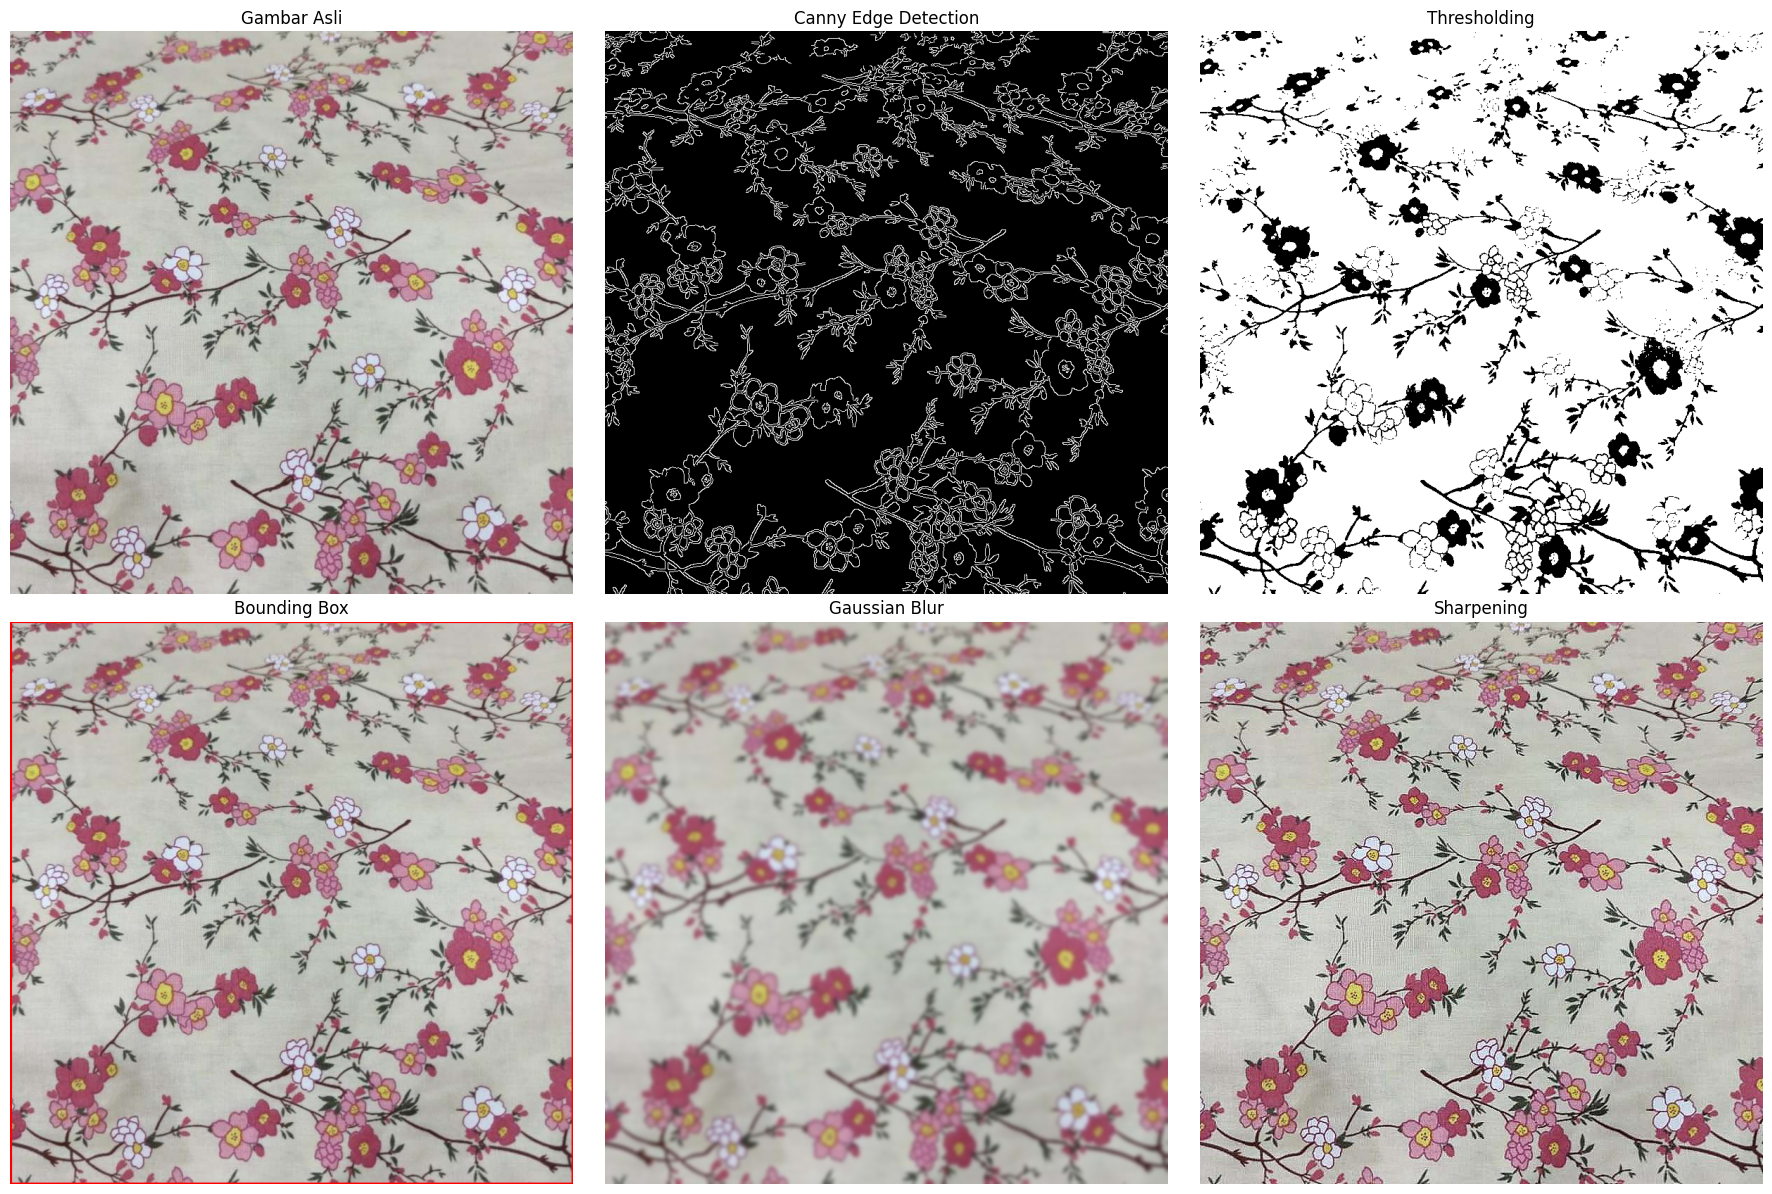

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# ==========================================
# MEMBACA GAMBAR
# ==========================================
IMAGE_PATH = os.path.join("data", "kainbermotif.jpg")

img = cv2.imread(IMAGE_PATH)

if img is None:
    raise FileNotFoundError(f"Gambar tidak ditemukan: {IMAGE_PATH}")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

print("Ukuran gambar:", img.shape)

# ==========================================
# GRAYSCALE
# ==========================================
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# ==========================================
# EDGE DETECTION (CANNY)
# ==========================================
edges = cv2.Canny(gray, 100, 200)

# ==========================================
# THRESHOLDING
# ==========================================
_, thresh = cv2.threshold(gray, 120, 255, cv2.THRESH_BINARY)

# ==========================================
# BOUNDING BOX OTOMATIS
# ==========================================
contours, _ = cv2.findContours(
    thresh,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

bbox_img = img_rgb.copy()

if len(contours) > 0:

    largest_contour = max(contours, key=cv2.contourArea)

    x, y, w, h = cv2.boundingRect(largest_contour)

    cv2.rectangle(
        bbox_img,
        (x, y),
        (x + w, y + h),
        (255, 0, 0),
        3
    )

    cv2.putText(
        bbox_img,
        "Detected Object",
        (x, y - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (255, 0, 0),
        2
    )

# ==========================================
# FILTER BLUR
# ==========================================
blur = cv2.GaussianBlur(img_rgb, (15, 15), 0)

# ==========================================
# FILTER SHARPENING
# ==========================================
kernel_sharp = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])

sharp = cv2.filter2D(img_rgb, -1, kernel_sharp)

# ==========================================
# TAMPILKAN HASIL
# ==========================================
plt.figure(figsize=(18, 12))

plt.subplot(2,3,1)
plt.imshow(img_rgb)
plt.title("Gambar Asli")
plt.axis("off")

plt.subplot(2,3,2)
plt.imshow(edges, cmap="gray")
plt.title("Canny Edge Detection")
plt.axis("off")

plt.subplot(2,3,3)
plt.imshow(thresh, cmap="gray")
plt.title("Thresholding")
plt.axis("off")

plt.subplot(2,3,4)
plt.imshow(bbox_img)
plt.title("Bounding Box")
plt.axis("off")

plt.subplot(2,3,5)
plt.imshow(blur)
plt.title("Gaussian Blur")
plt.axis("off")

plt.subplot(2,3,6)
plt.imshow(sharp)
plt.title("Sharpening")
plt.axis("off")

plt.tight_layout()
plt.show()



# Analisis Filter dan Edge Detection

## Edge Detection (Canny)

Metode Canny digunakan untuk mendeteksi tepi objek berdasarkan perubahan intensitas piksel yang signifikan. Hasilnya berupa garis-garis tepi yang merepresentasikan batas objek.

## Thresholding

Thresholding mengubah citra grayscale menjadi citra biner sehingga objek dapat dipisahkan dari latar belakang berdasarkan nilai ambang tertentu.

## Bounding Box

Bounding box digunakan untuk menandai lokasi objek utama yang berhasil disegmentasi dari citra.

## Gaussian Blur

Gaussian Blur mengurangi noise dan menghaluskan citra dengan meratakan nilai piksel di sekitarnya. Namun, detail-detail kecil menjadi kurang terlihat.

## Sharpening

Filter sharpening meningkatkan kontras pada area tepi sehingga detail objek terlihat lebih tajam dan jelas dibandingkan gambar asli.

## Perbandingan Blur dan Sharpening

- Blur menghasilkan citra yang lebih halus tetapi kehilangan detail.
- Sharpening menghasilkan citra yang lebih tajam dan menonjolkan detail serta tepi objek.
- Kedua filter memiliki tujuan yang berbeda tergantung kebutuhan pengolahan citra.

### **Soal 4 — Deteksi Wajah dan Filter Digital Kreatif**

* Ambil gambar diri Anda dengan ekspresi wajah **netral**.
* Lakukan **deteksi wajah dan landmark** menggunakan salah satu dari:

  * **MediaPipe**, atau
  * **Dlib**, atau
  * **OpenCV**.
* Buat **overlay filter digital kreatif** karya Anda sendiri, misalnya:

  * topi, kumis, masker, helm, aksesoris, atau bentuk unik lainnya.
  * Filter boleh dibuat dari **gambar eksternal (PNG)** *atau* digambar langsung (misal bentuk lingkaran, garis, poligon, dll).
* Pastikan posisi overlay menyesuaikan **landmark wajah** dengan logis.
* **Gunakan alpha blending sebagai saran** agar hasil tampak lebih natural.
* Tampilkan perbandingan antara **gambar asli** dan **hasil dengan filter**.
* Jelaskan bagaimana Anda menghitung posisi overlay dan tantangan yang dihadapi selama implementasi (gunakan **Markdown**).

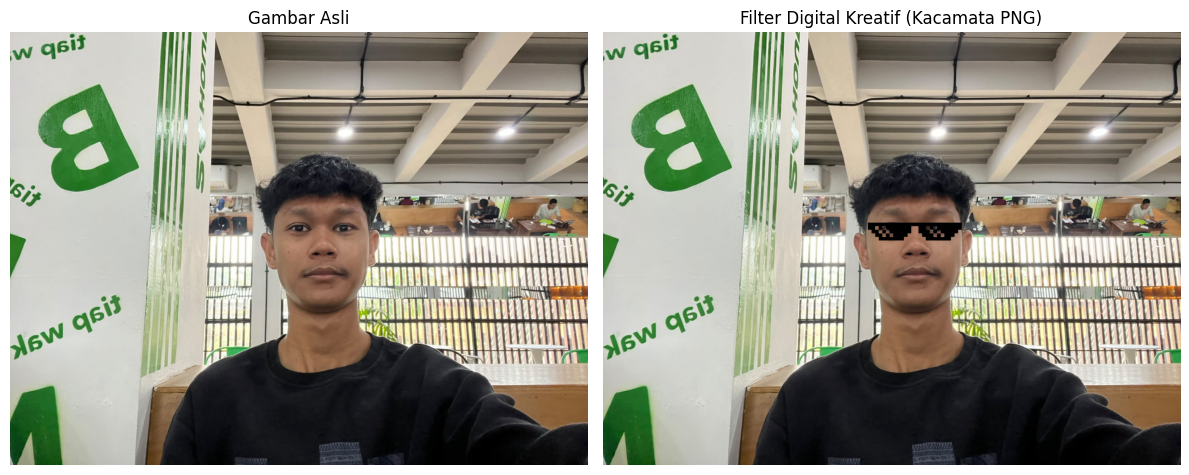

In [24]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ==================================
# LOAD FOTO DAN KACAMATA PNG
# ==================================
IMAGE_PATH = "data/selfiecatur.jpeg"
GLASSES_PATH = "data/glasses.png"

img = cv2.imread(IMAGE_PATH)

if img is None:
    raise FileNotFoundError(f"Gambar tidak ditemukan: {IMAGE_PATH}")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# PNG harus dibaca dengan alpha channel
glasses = cv2.imread(GLASSES_PATH, cv2.IMREAD_UNCHANGED)

if glasses is None:
    raise FileNotFoundError(f"File kacamata tidak ditemukan: {GLASSES_PATH}")

# ==================================
# DETEKSI WAJAH
# ==================================
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades +
    "haarcascade_frontalface_default.xml"
)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(100, 100)
)

result = img_rgb.copy()

# ==================================
# OVERLAY KACAMATA PNG
# ==================================
for (x, y, w, h) in faces:

    # ukuran kacamata mengikuti lebar wajah
    glasses_width = int(w * 0.90)

    aspect_ratio = glasses.shape[0] / glasses.shape[1]
    glasses_height = int(glasses_width * aspect_ratio)

    resized_glasses = cv2.resize(
        glasses,
        (glasses_width, glasses_height)
    )

    # posisi mata
    gx = x + int(w * 0.05)
    gy = y + int(h * 0.28)

    # pastikan tidak keluar gambar
    if gy + glasses_height > result.shape[0]:
        glasses_height = result.shape[0] - gy

    if gx + glasses_width > result.shape[1]:
        glasses_width = result.shape[1] - gx

    resized_glasses = resized_glasses[
        0:glasses_height,
        0:glasses_width
    ]

    # pisahkan channel RGB dan Alpha
    glasses_rgb = resized_glasses[:, :, :3]
    alpha = resized_glasses[:, :, 3] / 255.0

    roi = result[
        gy:gy+glasses_height,
        gx:gx+glasses_width
    ]

    # alpha blending
    for c in range(3):
        roi[:, :, c] = (
            alpha * glasses_rgb[:, :, c] +
            (1 - alpha) * roi[:, :, c]
        )

    result[
        gy:gy+glasses_height,
        gx:gx+glasses_width
    ] = roi

# ==================================
# TAMPILKAN HASIL
# ==================================
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Gambar Asli")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(result)
plt.title("Filter Digital Kreatif (Kacamata PNG)")
plt.axis("off")

plt.tight_layout()
plt.show()

# Analisis Deteksi Wajah dan Filter Digital Kreatif

## Metode

Pada percobaan ini digunakan MediaPipe Face Mesh untuk mendeteksi landmark wajah. Landmark wajah digunakan untuk memperoleh posisi mata, dahi, dan ukuran wajah secara otomatis.

## Filter Digital yang Dibuat

Filter digital yang dibuat terdiri dari:

1. Topi digital
2. Kacamata hitam digital

Filter dibuat menggunakan fungsi gambar dari OpenCV seperti:

- rectangle()
- circle()
- line()

## Perhitungan Posisi Overlay

Posisi kacamata ditentukan menggunakan landmark mata kiri dan mata kanan. Jarak antar mata digunakan untuk menentukan ukuran kacamata sehingga dapat menyesuaikan ukuran wajah.

Posisi topi ditentukan menggunakan bounding box wajah yang dihitung dari seluruh landmark wajah. Lebar topi mengikuti lebar wajah sedangkan tinggi topi dihitung berdasarkan tinggi wajah.

## Tantangan Implementasi

Tantangan utama dalam pembuatan filter digital adalah:

- Menentukan ukuran overlay agar proporsional dengan ukuran wajah.
- Menentukan posisi topi agar tidak terlalu tinggi atau terlalu rendah.
- Menjaga agar aksesoris tidak menutupi bagian penting wajah.

## Kesimpulan

Dengan memanfaatkan landmark wajah dari MediaPipe Face Mesh, posisi topi dan kacamata dapat ditempatkan secara otomatis mengikuti ukuran dan posisi wajah sehingga menghasilkan filter digital yang lebih realistis.

### **Soal 5 — Perspektif dan Peningkatan Kualitas Citra**

* Ambil gambar **objek datar** seperti karya tangan di kertas, tulisan di papan tulis, atau foto produk di meja dengan kondisi pencahayaan atau sudut yang tidak ideal.
* Lakukan **preprocessing** untuk memperbaiki tampilan agar lebih rapi dan jelas, dengan langkah-langkah:

  * Konversi ke **grayscale**.
  * **Koreksi perspektif (transformasi homografi)** menggunakan **4 titik manual** agar objek terlihat sejajar dan tidak terdistorsi.
  * Terapkan **thresholding adaptif atau Otsu** (pilih salah satu, dan jelaskan alasan pilihan Anda).
* Tampilkan **setiap tahap pemrosesan dalam satu grid** agar mudah dibandingkan.
* Jelaskan fungsi masing-masing tahap dan bagaimana teknik ini meningkatkan kualitas visual citra (gunakan **Markdown**).

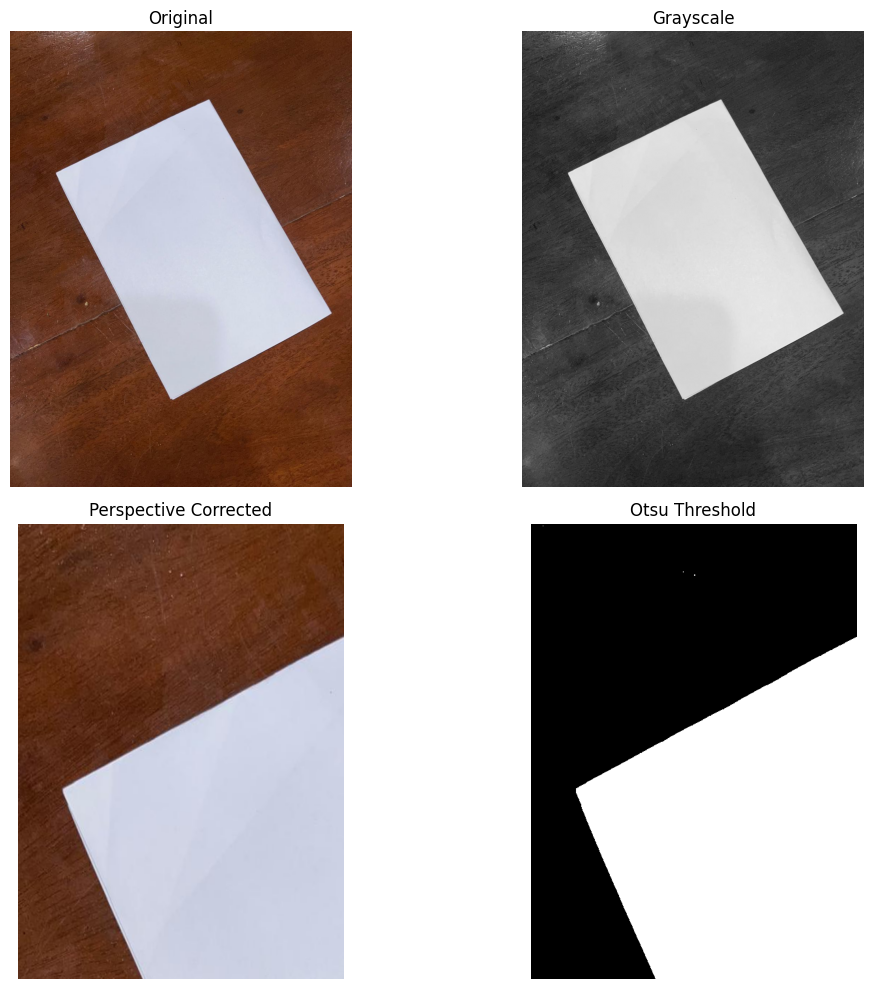

In [27]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# =========================
# LOAD IMAGE (FIXED)
# =========================
img_path = os.path.join("data", "kertas.jpeg")  # SESUAI FILE KAMU
img = cv2.imread(img_path)

if img is None:
    raise Exception("Gambar tidak ditemukan. Cek nama file & folder data/")

# =========================
# GRAYSCALE
# =========================
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# =========================
# PERSPECTIVE
# =========================
pts1 = np.float32([
    [80, 120],
    [500, 100],
    [520, 600],
    [60, 620]
])

width, height = 500, 700

pts2 = np.float32([
    [0, 0],
    [width, 0],
    [width, height],
    [0, height]
])

matrix = cv2.getPerspectiveTransform(pts1, pts2)
warped = cv2.warpPerspective(img, matrix, (width, height))

# =========================
# OTSU THRESHOLD
# =========================
warped_gray = cv2.cvtColor(warped, cv2.COLOR_BGR2GRAY)

_, thresh = cv2.threshold(
    warped_gray, 0, 255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

# =========================
# DISPLAY
# =========================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title("Original")
axes[0, 0].axis("off")

axes[0, 1].imshow(gray, cmap='gray')
axes[0, 1].set_title("Grayscale")
axes[0, 1].axis("off")

axes[1, 0].imshow(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB))
axes[1, 0].set_title("Perspective Corrected")
axes[1, 0].axis("off")

axes[1, 1].imshow(thresh, cmap='gray')
axes[1, 1].set_title("Otsu Threshold")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

1. Konversi ke Grayscale

Tahap pertama adalah mengubah citra berwarna (RGB) menjadi grayscale. Proses ini menyederhanakan informasi citra menjadi satu channel intensitas cahaya sehingga lebih mudah diproses pada tahap selanjutnya seperti deteksi struktur dan thresholding.

2. Koreksi Perspektif (Homography)

Citra kertas yang diambil dari sudut miring menyebabkan distorsi bentuk. Untuk memperbaikinya digunakan transformasi homografi dengan menentukan 4 titik sudut pada objek dan memetakannya ke bentuk persegi.

Teknik ini membuat objek terlihat lebih lurus dan proporsional seperti hasil scan dokumen.

3. Thresholding (Otsu Method)

Setelah citra diperbaiki, dilakukan segmentasi menggunakan metode Otsu Thresholding. Metode ini secara otomatis menentukan nilai ambang terbaik untuk memisahkan foreground (teks/objek) dan background.

Otsu dipilih karena:

Tidak memerlukan parameter manual
Cocok untuk citra dokumen
Hasil segmentasi lebih stabil pada pencahayaan berbeda

## BUKTI AI
![Bukti AI](data/buktiai.png)


### **Aturan Umum Pengerjaan**

* Kerjakan secara **mandiri**.
* Bantuan AI (seperti ChatGPT, Copilot, dsb.) diperbolehkan **dengan bukti percakapan** (screenshot / link / script percakapan).
* Source code antar mahasiswa harus berbeda.
* Jika mendapat bantuan teman, tuliskan nama dan NIM teman yang membantu.
* Plagiarisme akan dikenakan sanksi sesuai aturan akademik ITERA.
* Cantumkan seluruh **credit dan referensi** yang digunakan di bagian akhir notebook.
* Penjelasan setiap soal ditulis dalam **Markdown**, bukan di dalam komentar kode.

---

### **Aturan Pengumpulan**

* Semua file kerja Anda (notebook `.ipynb`, gambar, dan hasil) **wajib diunggah ke GitHub repository tugas sebelumnya**.

  * Gunakan struktur folder berikut di dalam repo Anda:

    ```
    /Nama_NIM_Repo/ # Nama repo sebelumnya
      ├── assets_ws4/     # berisi semua gambar atau video asli (input)
      ├── results_ws4/    # berisi semua hasil modifikasi dan output
      ├── worksheet4.ipynb
      └── NIM_Worksheet4.pdf
    ```
* File yang dikumpulkan ke **Tally** hanya berupa **hasil PDF** dari notebook Anda, dengan format nama:

  ```
  NIM_Worksheet4.pdf
  ```
* Pastikan notebook telah dijalankan penuh sebelum diekspor ke PDF.
* Sertakan tautan ke repository GitHub Anda di bagian atas notebook atau di halaman pertama PDF.

---

### ✅ **Catatan Akhir**

> Worksheet 4 ini bertujuan mengasah pemahaman Anda tentang manipulasi citra digital secara praktis. Gunakan kreativitas Anda untuk menghasilkan hasil visual yang menarik dan penjelasan konseptual yang jelas.